In [1]:
# Import required libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

C:\Users\shiva\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\shiva\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Load cash flow dataset
df = pd.read_csv("../data/cash_flow_data.csv")

# Display first five rows
df.head()

,date,operating_cash_flow,investing_cash_flow,financing_cash_flow,current_assets,current_liabilities
0,2023-01-31,85000,-22000,-12000,310000,185000
1,2023-02-28,78000,-18000,-11000,318000,190000
2,2023-03-31,92000,-25000,-13000,330000,198000
3,2023-04-30,74000,-16000,-12000,325000,202000
4,2023-05-31,68000,-14000,-11000,320000,205000


In [3]:
# Check dataset information

print(df.shape)
print(df.info())

(30, 6)
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   date                 30 non-null     str  
 1   operating_cash_flow  30 non-null     int64
 2   investing_cash_flow  30 non-null     int64
 3   financing_cash_flow  30 non-null     int64
 4   current_assets       30 non-null     int64
 5   current_liabilities  30 non-null     int64
dtypes: int64(5), str(1)
memory usage: 1.5 KB
None


In [4]:
# Convert date column into datetime format
df["date"] = pd.to_datetime(df["date"])

# Set date as index for time-series analysis
df = df.set_index("date")

df.head()

,operating_cash_flow,investing_cash_flow,financing_cash_flow,current_assets,current_liabilities
date,,,,,
2023-01-31,85000,-22000,-12000,310000,185000
2023-02-28,78000,-18000,-11000,318000,190000
2023-03-31,92000,-25000,-13000,330000,198000
2023-04-30,74000,-16000,-12000,325000,202000
2023-05-31,68000,-14000,-11000,320000,205000


In [5]:
# Check missing values in each column
df.isnull().sum()

operating_cash_flow    0
investing_cash_flow    0
financing_cash_flow    0
current_assets         0
current_liabilities    0
dtype: int64

In [6]:
# Calculate total net cash flow for each month
df["net_cash_flow"] = (
    df["operating_cash_flow"]
    + df["investing_cash_flow"]
    + df["financing_cash_flow"]
)
df[[
    "operating_cash_flow",
    "investing_cash_flow",
    "financing_cash_flow",
    "net_cash_flow"
]].head()

,operating_cash_flow,investing_cash_flow,financing_cash_flow,net_cash_flow
date,,,,
2023-01-31,85000,-22000,-12000,51000
2023-02-28,78000,-18000,-11000,49000
2023-03-31,92000,-25000,-13000,54000
2023-04-30,74000,-16000,-12000,46000
2023-05-31,68000,-14000,-11000,43000


In [7]:
# Set beginning cash balance
beginning_cash = 250000

# Calculate ending cash balance over time
df["ending_cash_balance"] = beginning_cash + df["net_cash_flow"].cumsum()
df[[
    "net_cash_flow",
    "ending_cash_balance"
]].head()

,net_cash_flow,ending_cash_balance
date,,
2023-01-31,51000,301000
2023-02-28,49000,350000
2023-03-31,54000,404000
2023-04-30,46000,450000
2023-05-31,43000,493000


In [8]:
# Calculate working capital
df["working_capital"] = (
    df["current_assets"]
    - df["current_liabilities"]
)

df[[
    "current_assets",
    "current_liabilities",
    "working_capital"
]].head()

,current_assets,current_liabilities,working_capital
date,,,
2023-01-31,310000,185000,125000
2023-02-28,318000,190000,128000
2023-03-31,330000,198000,132000
2023-04-30,325000,202000,123000
2023-05-31,320000,205000,115000


In [9]:
# # Estimate average montly cash outflow
average_monthly_outflow = abs(
    df[df["net_cash_flow"]< 0]["net_cash_flow"].mean()
)
# Calculate liquidity runway in months

df["liquidity_runway_months"] = (
    df["ending_cash_balance"] / average_monthly_outflow
)

df[[
    "ending_cash_balance",
    "liquidity_runway_months"
]].head()

,ending_cash_balance,liquidity_runway_months
date,,
2023-01-31,301000,NaN
2023-02-28,350000,NaN
2023-03-31,404000,NaN
2023-04-30,450000,NaN
2023-05-31,493000,NaN


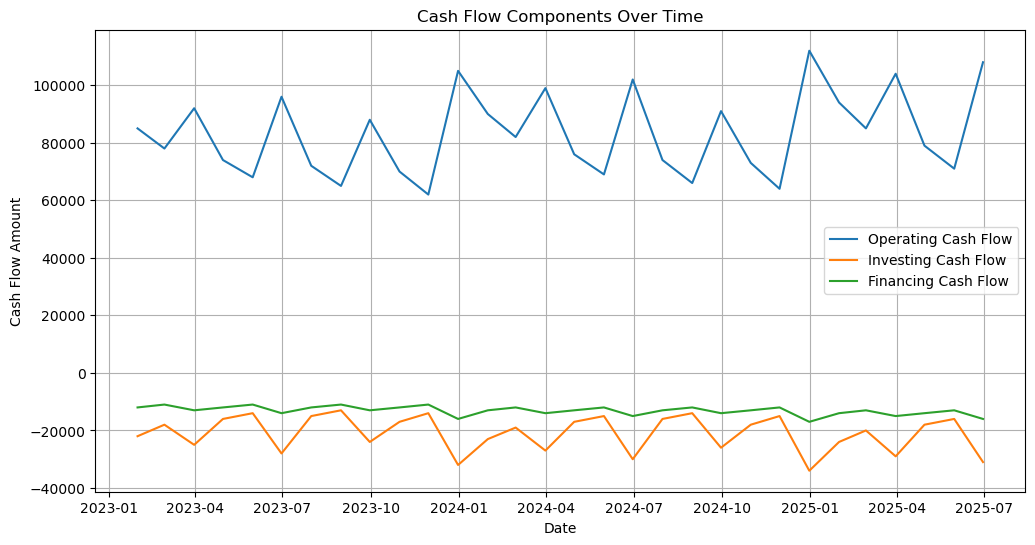

In [10]:
# Plot operating, investing, and financing cash flows
plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["operating_cash_flow"],
    label="Operating Cash Flow"
)

plt.plot(
    df.index,
    df["investing_cash_flow"],
    label="Investing Cash Flow"
)

plt.plot(
    df.index,
    df["financing_cash_flow"],
    label="Financing Cash Flow"
)

plt.title("Cash Flow Components Over Time")
plt.xlabel("Date")
plt.ylabel("Cash Flow Amount")

plt.legend()
plt.grid(True)

plt.savefig("../visuals/cash_flow_components.png")

plt.show()

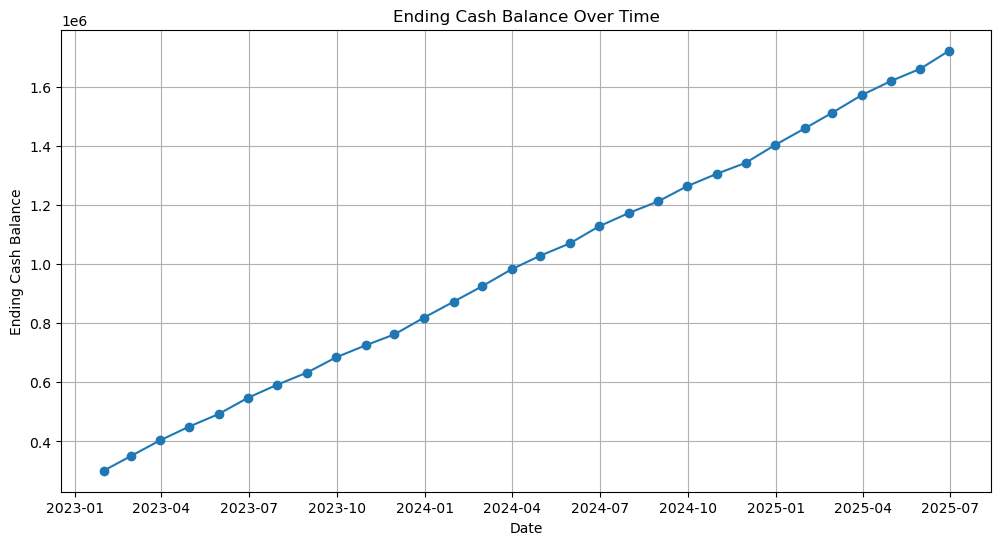

In [11]:
# Plot ending cash balance
plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["ending_cash_balance"],
    marker="o"
)

plt.title("Ending Cash Balance Over Time")
plt.xlabel("Date")
plt.ylabel("Ending Cash Balance")

plt.grid(True)

plt.savefig("../visuals/ending_cash_balance.png")

plt.show()

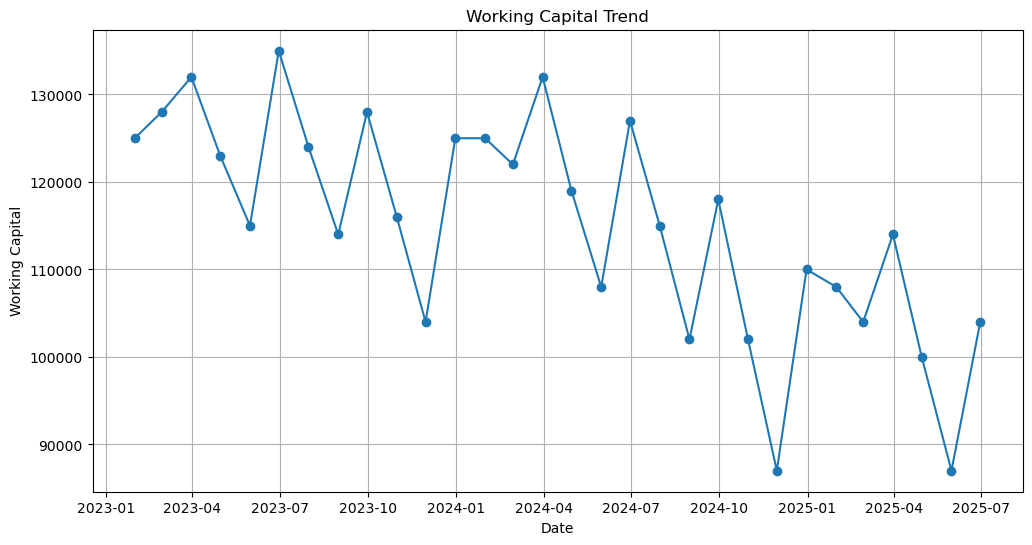

In [12]:
# Plot working capital trend
plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["working_capital"],
    marker="o"
)

plt.title("Working Capital Trend")
plt.xlabel("Date")
plt.ylabel("Working Capital")

plt.grid(True)

plt.savefig("../visuals/working_capital_trend.png")

plt.show()

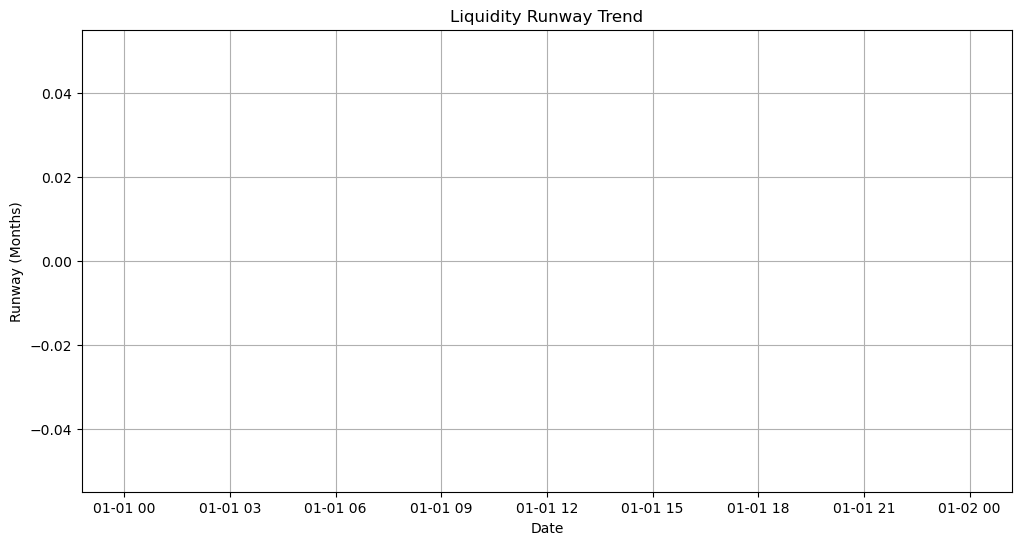

In [13]:
# Plot liquidity runway trend
plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["liquidity_runway_months"],
    marker="o"
)

plt.title("Liquidity Runway Trend")
plt.xlabel("Date")
plt.ylabel("Runway (Months)")

plt.grid(True)

plt.savefig("../visuals/liquidity_runway_trend.png")

plt.show()